# ============================================================
# Name: Boualem Marir                                              
# Student Number: GEM/25/AIDS/1002
# School: Grenoble Ecole de Management – Alpine Business School
# Program: Master in Artificial Intelligence and Data Science

# Module: AIN7303 – Machine Learning and Deep Learning Techniques
# Faculty: Dr. David
# ============================================================

# ============================================================
# ASSIGNMENT 2 – Advanced Supervised Machine Learning
# CarDekho: Used car prices forecasting
# ============================================================

# ────────────────────────────────────────────────────────────
# Introduction
# ────────────────────────────────────────────────────────────
# This assignment applies the Week 2 machine learning workflow to the CarDekho dataset to classify used cars as high-price or low-price using Logistic Regression, Decision Tree, and K-Nearest Neighbors.

# I followed the full pipeline: preprocessing, binary target creation, model training, evaluation,
# and comparative analysis.

# The assignment is divided into two parts to understand the impact of feature scaling on model performance. My focus was on understanding why each step matters rather than just producing results.

# Throughout the notebook I included observations and interpretations to critically reflect on the differences between models and the role that preprocessing plays in machine learning outcomes.

# ============================================================
# PART A: Without Feature Scaling
# ============================================================

In [1]:
# ============================================================
# Step-A-01: Import Required Libraries
# ============================================================

import pandas as pd                                           # data loading and manipulation
import numpy as np                                            # numerical operations
import matplotlib.pyplot as plt                               # plotting and visualisation
import seaborn as sns                                         # statistical visualisation (e.g. confusion matrix heatmaps)

from sklearn.model_selection import train_test_split          # split data into training and testing sets
from sklearn.preprocessing import LabelEncoder                # encode categorical variables into numeric format
from sklearn.linear_model import LogisticRegression           # logistic regression classifier
from sklearn.tree import DecisionTreeClassifier               # decision tree classifier
from sklearn.neighbors import KNeighborsClassifier            # k-nearest neighbours classifier
from sklearn.metrics import (accuracy_score,                  # overall prediction accuracy
                             confusion_matrix,                # actual vs predicted class breakdown
                             classification_report)           # precision, recall, F1-score per class

print("All libraries imported successfully.")

All libraries imported successfully.


In [9]:
# ============================================================
# Step-A-02: Load the Dataset
# ============================================================
df = pd.read_csv("CAR DEKHO.csv", encoding="ISO-8859-1")     # load dataset with encoding to handle special characters

print("Dataset shape:", df.shape)                             # confirm number of rows and columns
print("\nFirst 5 rows:")
df.head()                                                     # preview the first 5 rows

Dataset shape: (4340, 8)

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [10]:
# ============================================================
# Step-A-03: Create the Binary Target Variable
# ============================================================

# Classify cars as high-price (1) or low-price (0) based on a threshold of 300,000 (as done in the class)
df["is_expensive"] = (df["selling_price"] >= 300000).astype(int)

print("Selling Price Binary Target Variable:")
print(df["is_expensive"].value_counts())                      # check class balance: 0 = Low Price, 1 = High Price

Selling Price Binary Target Variable:
is_expensive
1    2617
0    1723
Name: count, dtype: int64


# Code worked, we have 2617 cars considered High price, and 1723 cars considered Low price

In [11]:
# ============================================================
# Step-A-04: 4.	Perform preprocessing (drop columns, encoding)
# ============================================================

# Drop 'name' (unique identifier, adds no predictive value) and 'selling_price' (replaced by the binary target 'is_expensive')
df = df.drop(columns=["name", "selling_price"])

# One-Hot Encoding converts categorical text columns into binary (0/1) numerical columns
# drop_first=True drops one dummy column per feature to avoid multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df, drop_first=True) # One-Hot Encode all remaining categorical columns (fuel, seller_type, transmission, owner)

print("Encoded dataset shape:", df_encoded.shape)             # confirm number of features after encoding
print("\nEncoded columns:", df_encoded.columns.tolist())      # inspect the new column names after encoding
df_encoded.head()                                             # preview encoded dataset

Encoded dataset shape: (4340, 14)

Encoded columns: ['year', 'km_driven', 'is_expensive', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


,year,km_driven,is_expensive,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,70000,0,False,False,False,True,True,False,True,False,False,False,False
1,2007,50000,0,False,False,False,True,True,False,True,False,False,False,False
2,2012,100000,1,True,False,False,False,True,False,True,False,False,False,False
3,2017,46000,0,False,False,False,True,True,False,True,False,False,False,False
4,2014,141000,1,True,False,False,False,True,False,True,False,True,False,False


# The dataset now has 14 columns: 2 numerical (year, km_driven), 1 binary target (is_expensive),
# and 11 One-Hot Encoded dummy columns representing the categorical features.
# All features are now in numerical format, ready for model training.

In [12]:
# ============================================================
# Step-A-05: Define X and y
# ============================================================

# X → all feature columns (independent variables used to make predictions)
# y → binary target variable (0 = Low Price, 1 = High Price)

X = df_encoded.drop(columns=["is_expensive"])                 # drop target to isolate input features
y = df_encoded["is_expensive"]                                # target variable

print("Features shape (X):", X.shape)                        # confirm number of samples and features
print("Target shape (y):", y.shape)                          # confirm target vector dimensions

Features shape (X): (4340, 13)
Target shape (y): (4340,)


In [14]:
# ============================================================
# Step-A-06: Split Data into Training and Testing Sets
# ============================================================

# 80% training — model learns patterns from this portion
# 20% testing  — model is evaluated on unseen data to measure generalisation
# random_state=42 ensures reproducibility: same split every time the code is run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)                    # confirm training data dimensions
print("Testing set size:", X_test.shape)                      # confirm testing data dimensions

Training set size: (3472, 13)
Testing set size: (868, 13)


In [44]:
# ============================================================
# Step-A-07: Train Models on Unscaled Data
# ============================================================

# --- Model 1: Logistic Regression ---

# Logistic Regression is a supervised machine learning algorithm used for binary classification
# A linear probability-based classifier that outputs a probability between 0 and 1
# max_iter=1200 ensures the model has enough iterations to converge

log_model = LogisticRegression(max_iter=1000)                 # initialise logistic regression model
log_model.fit(X_train, y_train)                               # train model on unscaled training data
log_preds = log_model.predict(X_test)                         # generate predictions on test data

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Note on Convergence Warning:
# The warning above tells us that Logistic Regression did not fully converge within 1000 iterations
# This happens because the features are on very different scales making the optimisation process unstable
# The warning itself suggests scaling the data as a solution which is exactly what we do in Part B
# This makes the warning a useful indicator rather than just an error to ignore

# this note was written after completing the assignment, which made me reflect on it and put it here.

In [26]:
# --- Model 2: Decision Tree ---

# As explained in the class material:
# A rule-based model that splits the data into branches based on feature thresholds
# No max_iter needed: Decision Trees are not iterative, they learn by splitting
# Scaling is not required: splits are based on thresholds, not distances or magnitudes

tree_model = DecisionTreeClassifier()                         # initialise decision tree with default parameters
tree_model.fit(X_train, y_train)                              # train model on unscaled training data
tree_preds = tree_model.predict(X_test)                       # generate predictions on test data

In [27]:
# --- Model 3: K-Nearest Neighbors (K-NN) ---

# Instance-based model that classifies by majority vote among the 5 nearest neighbours (same as in the week 02 / day 2 codes)
# Sensitive to feature scaling — without scaling, features with larger ranges dominate distance calculations

knn_model = KNeighborsClassifier(n_neighbors=5)               # initialise KNN with k=5 neighbours
knn_model.fit(X_train, y_train)                               # train model on unscaled training data
knn_preds = knn_model.predict(X_test)                         # generate predictions on test data

In [28]:
# ============================================================
# Step-A-08/01: Evaluate Each Model Using: Accuracy
# ============================================================

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_preds))          # overall accuracy for logistic regression

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, tree_preds))         # overall accuracy for decision tree

print("\n=== K-Nearest Neighbors ===")
print("Accuracy:", accuracy_score(y_test, knn_preds))          # overall accuracy for KNN

=== Logistic Regression ===
Accuracy: 0.7603686635944701

=== Decision Tree ===
Accuracy: 0.815668202764977

=== K-Nearest Neighbors ===
Accuracy: 0.7361751152073732


# Accuracy Interpretation:
# Decision Tree achieves the highest accuracy (81.6%), followed by Logistic Regression (76.0%) and KNN (73.6%)
# KNN's lower accuracy is expected at this stage as it is sensitive to feature scaling which has not been applied yet
# These results serve as our baseline before scaling is introduced in Part B (Comparison part)

=== Logistic Regression ===
Confusion Matrix:
 [[206 144]
 [ 64 454]]

=== Decision Tree ===
Confusion Matrix:
 [[283  67]
 [ 93 425]]

=== K-Nearest Neighbors ===
Confusion Matrix:
 [[223 127]
 [102 416]]


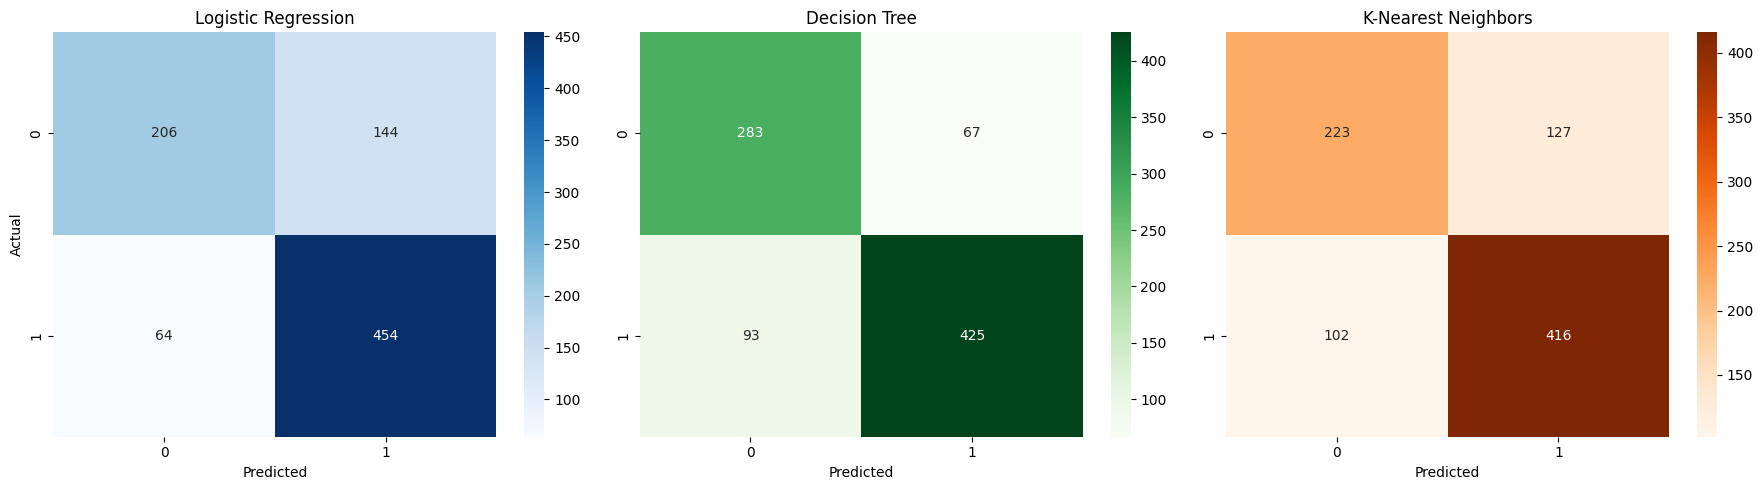

In [30]:
# ============================================================
# Step-A-08/02: Evaluate Each Model Using: Confusion Matrix
# ============================================================

# Confusion matrix breakdown: rows = actual class, columns = predicted class
# Diagonal values (top-left, bottom-right) represent correct predictions
print("=== Logistic Regression ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))

print("\n=== Decision Tree ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, tree_preds))

print("\n=== K-Nearest Neighbors ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_preds))

# Visualise confusion matrices as heatmaps (Strong diagonal values indicate correct predictions)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, log_preds),
            annot=True, fmt='d', ax=axes[0], cmap='Blues')    # Blue for Logistic Regression
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, tree_preds),
            annot=True, fmt='d', ax=axes[1], cmap='Greens')   # Green for Decision Tree
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, knn_preds),
            annot=True, fmt='d', ax=axes[2], cmap='Oranges')  # Orange for KNN
axes[2].set_title('K-Nearest Neighbors')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Confusion Matrix Interpretation:

# Decision Tree has the strongest results: fewest misclassifications across both classes
# Logistic Regression misclassifies 144 low-price cars as high-price
# KNN shows the weakest performance, confirming its sensitivity to unscaled features

In [32]:
# ============================================================
# Step-A-08/03: Evaluate Each Model — Classification Report
# ============================================================

# Below are from Week 01/02 class material:
# precision = how many predicted high/low price cars were correctly classified
# recall    = how many actual high/low price cars were correctly identified
# F1-score  = balance between precision and recall
# support   = number of actual instances per class in the test set

print("=== Logistic Regression ===")
print("Classification Report:\n", classification_report(y_test, log_preds))

print("\n=== Decision Tree ===")
print("Classification Report:\n", classification_report(y_test, tree_preds))

print("\n=== K-Nearest Neighbors ===")
print("Classification Report:\n", classification_report(y_test, knn_preds))

=== Logistic Regression ===
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.59      0.66       350
           1       0.76      0.88      0.81       518

    accuracy                           0.76       868
   macro avg       0.76      0.73      0.74       868
weighted avg       0.76      0.76      0.75       868


=== Decision Tree ===
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       350
           1       0.86      0.82      0.84       518

    accuracy                           0.82       868
   macro avg       0.81      0.81      0.81       868
weighted avg       0.82      0.82      0.82       868


=== K-Nearest Neighbors ===
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.64      0.66       350
           1       0.77      0.80      0.78       518

    accuracy                  

# Classification Report Interpretation:

# Decision Tree gives the most balanced results, it predicts both low and high price cars well

# Logistic Regression is better at catching high-price cars (recall 0.88) but misses many low-price ones (recall 0.59)

# KNN struggles across both classes; without scaling, features with larger numeric ranges dominate the distance calculation

# The test set contains 350 low-price and 518 high-price cars, meaning the classes are slightly imbalanced.

# ============================================================
# Part A Summary
# ============================================================

# Three models were trained on unscaled data to classify cars as high-price or low-price
# Decision Tree achieved the highest accuracy (81.6%) with balanced precision and recall across both classes
# Logistic Regression performed moderately (76.0%) but showed a convergence warning ==> a sign that scaling is needed
# KNN recorded the lowest accuracy (73.6%) as expected ==> distance-based models are sensitive to unscaled features
# These results establish our baseline and highlight the importance of feature scaling, which we address in Part B next.

# ============================================================
# Part B: With Feature Scaling
# ============================================================

In [34]:
# ============================================================
# Step-B-01: Apply StandardScaler to Feature Data
# ============================================================

from sklearn.preprocessing import StandardScaler              # import scaler for Part B

# StandardScaler transforms all features to mean=0 and std=1
# fit_transform on training data: learns the mean and std from training data only
# transform on test data only: applies the same scale without refitting to prevent data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)                # fit on training data and transform
X_test_scaled  = scaler.transform(X_test)                     # transform test data only — no fit

In [35]:
# ============================================================
# Step-B-02/01: Train Models on Scaled Data - Logistic Regression
# ============================================================

# Scaling improves numerical stability and convergence speed

log_model_scaled = LogisticRegression(max_iter=1000)          # initialise logistic regression model
log_model_scaled.fit(X_train_scaled, y_train)                 # train on scaled training data
log_preds_scaled = log_model_scaled.predict(X_test_scaled)    # generate predictions on scaled test data

In [36]:
# ============================================================
# Step-B-02/02: Train Models on Scaled Data - K-Nearest Neighbors
# ============================================================

# Expected to show the most significant improvement; distance-based model benefits most from scaling

knn_model_scaled = KNeighborsClassifier(n_neighbors=5)        # initialise KNN with k=5
knn_model_scaled.fit(X_train_scaled, y_train)                 # train on scaled training data
knn_preds_scaled = knn_model_scaled.predict(X_test_scaled)    # generate predictions on scaled test data

In [37]:
# ============================================================
# Step-B-03: Train Decision Tree on Unscaled Data
# ============================================================

# Decision Tree does not require scaling; use the original unscaled data for a valid comparison baseline

tree_model_scaled = DecisionTreeClassifier()                  # initialise decision tree
tree_model_scaled.fit(X_train, y_train)                       # train on original unscaled data
tree_preds_scaled = tree_model_scaled.predict(X_test)         # generate predictions on unscaled test data

In [38]:
# ============================================================
# Step-B-04/01: Evaluate Each Model using: Accuracy
# ============================================================

# Accuracy = proportion of correctly classified cars out of total predictions

print("=== Logistic Regression (Scaled) ===")
print("Accuracy:", accuracy_score(y_test, log_preds_scaled))   # overall accuracy for logistic regression

print("\n=== Decision Tree (Unscaled) ===")
print("Accuracy:", accuracy_score(y_test, tree_preds_scaled))  # overall accuracy for decision tree

print("\n=== K-Nearest Neighbors (Scaled) ===")
print("Accuracy:", accuracy_score(y_test, knn_preds_scaled))   # overall accuracy for KNN

=== Logistic Regression (Scaled) ===
Accuracy: 0.8444700460829493

=== Decision Tree (Unscaled) ===
Accuracy: 0.8168202764976958

=== K-Nearest Neighbors (Scaled) ===
Accuracy: 0.8099078341013825


# Accuracy Interpretation:

# Logistic Regression achieves the highest accuracy at 84.4%: a strong result for a linear model
# Decision Tree follows closely at 81.6%
# KNN reaches 81.0%; a competitive result showing that scaling allowed the model to measure distances fairly

=== Logistic Regression (Scaled) ===
Confusion Matrix:
 [[267  83]
 [ 52 466]]

=== K-Nearest Neighbors (Scaled) ===
Confusion Matrix:
 [[272  78]
 [ 87 431]]

=== Decision Tree (Unscaled) ===
Confusion Matrix:
 [[285  65]
 [ 94 424]]


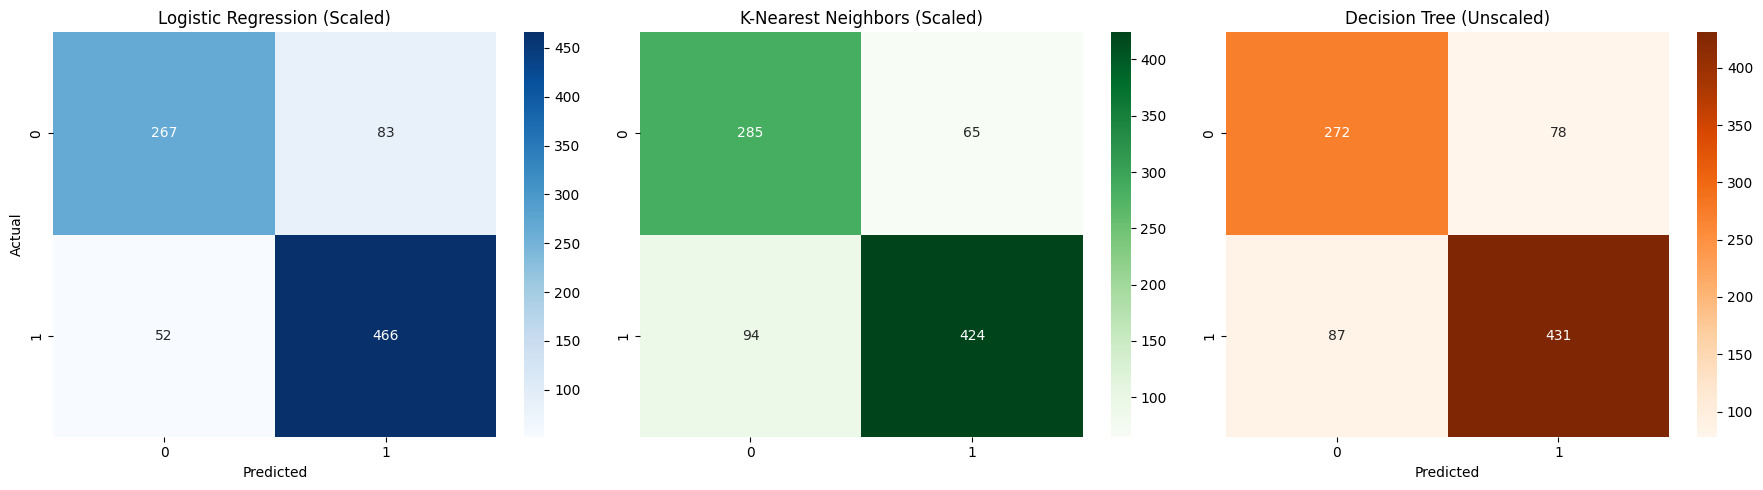

In [42]:
# ============================================================
# Step-B-04/02: Evaluate Each Model Using: Confusion Matrix
# ============================================================

# Confusion matrix breakdown: rows = actual class, columns = predicted class
# Diagonal values (top-left, bottom-right) represent correct predictions

print("=== Logistic Regression (Scaled) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds_scaled))

print("\n=== K-Nearest Neighbors (Scaled) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_preds_scaled))

print("\n=== Decision Tree (Unscaled) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, tree_preds_scaled))

# Visualise confusion matrices as heatmaps (Strong diagonal values indicate correct predictions)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, log_preds_scaled),
            annot=True, fmt='d', ax=axes[0], cmap='Blues')    # Blue for Logistic Regression
axes[0].set_title('Logistic Regression (Scaled)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, knn_preds_scaled),
            annot=True, fmt='d', ax=axes[2], cmap='Oranges')  # Orange for KNN
axes[1].set_title('K-Nearest Neighbors (Scaled)')
axes[1].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, tree_preds_scaled),
            annot=True, fmt='d', ax=axes[1], cmap='Greens')   # Green for Decision Tree
axes[2].set_title('Decision Tree (Unscaled)')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Confusion Matrix Interpretation:

# Logistic Regression correctly classifies 267 low-price and 466 high-price cars with relatively few misclassifications
# Decision Tree correctly classifies 285 low-price and 424 high-price cars: strongest result for low-price detection
# KNN correctly classifies 272 low-price and 431 high-price cars.

In [43]:
# ============================================================
# Step-B-04/03: Evaluate Each Model Using: Classification Report
# ============================================================

# precision = how many predicted high/low price cars were correctly classified
# recall    = how many actual high/low price cars were correctly identified
# F1-score  = balance between precision and recall
# support   = number of actual instances per class in the test set

print("=== Logistic Regression (Scaled) ===")
print("Classification Report:\n", classification_report(y_test, log_preds_scaled))

print("\n=== Decision Tree (Unscaled) ===")
print("Classification Report:\n", classification_report(y_test, tree_preds_scaled))

print("\n=== K-Nearest Neighbors (Scaled) ===")
print("Classification Report:\n", classification_report(y_test, knn_preds_scaled))

=== Logistic Regression (Scaled) ===
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.76      0.80       350
           1       0.85      0.90      0.87       518

    accuracy                           0.84       868
   macro avg       0.84      0.83      0.84       868
weighted avg       0.84      0.84      0.84       868


=== Decision Tree (Unscaled) ===
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78       350
           1       0.87      0.82      0.84       518

    accuracy                           0.82       868
   macro avg       0.81      0.82      0.81       868
weighted avg       0.82      0.82      0.82       868


=== K-Nearest Neighbors (Scaled) ===
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77       350
           1       0.85      0.83      0.84       518

 

# Classification Report Interpretation:

# Logistic Regression gives the best results in Part B with F1-score of 0.80 for low-price and 0.87 for high-price cars
# It predicts both low-price and high-price cars well with precision and recall above 0.84

# Decision Tree shows consistent results with F1-score of 0.78 for low-price and 0.84 for high-price cars

# KNN performs similarly to Decision Tree with F1-score of 0.77 for low-price and 0.84 for high-price cars.

# ============================================================
# Comparative Analysis
# ============================================================

# 01- Changes in Accuracy Across Models (PArt A and Part B):

# Model                        Part A (Unscaled)    Part B (Scaled)
# Logistic Regression          76.0%                84.4%
# Decision Tree                81.6%                81.6%
# K-Nearest Neighbors          73.6%                81.0%

# The accuracy results tell a clear story about how sensitive each model is to feature scaling

# The accuracy results tell a clear story about how sensitive each model is to feature scaling

# Logistic Regression had the most to gain from scaling and delivered the biggest improvement at 8.4 percentage points
# In Part A the model struggled to converge which directly hurt its accuracy
# Once the features were standardised the optimisation process stabilised and the model performed significantly better.

# KNN improved by 7.4 percentage points which was expected given that it classifies based on distance
# In Part A features with larger numeric ranges were pulling the distance calculation in their favour making the model unreliable regardless of how relevant those features actually were.

# Decision Tree stayed at 81.6% in both parts which is not a coincidence. It does not compute distances or optimise coefficients so the scale of features simply does not matter
# This consistency makes it a useful reference point when evaluating the impact of scaling on other models


# 02- Differences in Precision, Recall and F1-score

# Model                   Metric        Part A (Unscaled)    Part B (Scaled)
# Logistic Regression     Precision     0.76 / 0.76          0.84 / 0.85
#                         Recall        0.59 / 0.88          0.76 / 0.90
#                         F1-score      0.66 / 0.81          0.80 / 0.87
#
# Decision Tree           Precision     0.75 / 0.86          0.75 / 0.87
#                         Recall        0.81 / 0.82          0.81 / 0.82
#                         F1-score      0.78 / 0.84          0.78 / 0.84
#
# K-Nearest Neighbors     Precision     0.69 / 0.77          0.76 / 0.85
#                         Recall        0.64 / 0.80          0.78 / 0.83
#                         F1-score      0.66 / 0.78          0.77 / 0.84
# Note: Low-price (0) / High-price (1)

# Logistic Regression improved across all metrics after scaling
# The most striking change was in recall for low-price cars which jumped from 0.59 to 0.76
# In Part A the model was missing many low-price cars and classifying them as high-price
# Scaling stabilised the model and allowed it to identify both categories more reliably
# The F1-score for low-price cars improved from 0.66 to 0.80 which is a meaningful improvement.
#
# Decision Tree metrics were identical in both parts
# Precision recall and F1-score did not change at all which directly confirms what the course material states
# that tree-based models are unaffected by feature scaling since they split on conditions not magnitudes.
#
# KNN improved steadily across all metrics after scaling
# Precision recall and F1-score increased for both low-price and high-price cars
# In Part A the model was struggling because features were not on the same scale
# which made distance calculations unreliable and biased towards features with larger ranges
# Scaling corrected this and the improvement in metrics reflects that.


# 03- Which Model Improved the Most After Scaling and Why
#
# Logistic Regression improved the most in terms of accuracy gaining 8.4 percentage points
# However looking at the overall picture across all metrics KNN showed the most consistent and meaningful improvement

# In Part A KNN had the weakest results across accuracy precision recall and F1-score. After scaling all its metrics improved significantly bringing it in line with the other two models. The reason for this improvement is straightforward:
# KNN is a distance-based model and it classifies new data points by measuring how close they are to their neighbours.
# When features are on very different scales the distance calculation becomes biased. Features with larger numeric ranges end up having more influence simply because of their size not their relevance. Scaling puts all features on the same level and gives the model a fair basis for comparison.
#
# Logistic Regression also improved significantly and the convergence warning in Part A explained why the optimisation process was struggling with features on very different scales. Scaling resolved this and the model converged properly leading to better predictions.
#
# Decision Tree did not improve because it does not need to. It splits data based on feature conditions not distances or magnitudes, so scaling simply has no effect on how it learns or predicts. This makes it the most robust model in this assignment in terms of preprocessing requirements.

# ──────────────────────────────────────────────────────────────────────────────
# Conclusion, Learning and Reflection
# ──────────────────────────────────────────────────────────────────────────────
# This assignment built directly on what we did in Week 1 and showed me how the same dataset can be approached very differently depending on how the problem is framed.
# In Week 1 we predicted a continuous price and in Week 2 we asked a simpler but equally useful question: is this car expensive or not and that shift in thinking changed everything from the algorithm choice to the evaluation metrics.
#
# The most valuable lesson for me was seeing the real impact of feature scaling. I knew from the course material that KNN and Logistic Regression are sensitive to feature scale but seeing the convergence warning in Part A and then watching the accuracy jump after scaling made that concept click in a way that reading about it alone would not have.
#
# The comparison between the three models also gave me a clearer sense of when to use each algorithm. Decision Tree was the most straightforward to work with since it required no scaling and produced consistent results but Logistic Regression ultimately performed best once the data was properly prepared. That tells me that preprocessing decisions are just as important as model selection.
#
# Overall this assignment taught me that understanding why a model behaves the way it does is more important than just running the code and reporting the numbers. 
# The convergence warning, the accuracy differences and the unchanged Decision Tree results, all told a story and being able to read and explain that story is what machine learning is really about.